# 5.4. 교환자와 불확정성

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e

L, N = 1e-9, 3000
dx = L / (N + 1)
xg = np.linspace(0, L, N + 2)[1:-1]
D1 = (np.eye(N, k=1) - np.eye(N, k=-1)) / (2 * dx)
D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


def psi(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * xg / L)


print(f"{'n':>2} {'σx/L':>9} {'σp (h/L)':>10} {'σx * σp (hbar)':>15}")
for n in [1, 2, 3, 4, 5]:
    p = psi(n)
    x_mean = np.trapezoid(p * xg * p, xg)
    x2_mean = np.trapezoid(p * xg**2 * p, xg)
    p2_mean = np.trapezoid(p * (-(hbar**2) * (D2 @ p)), xg)

    sigma_x = np.sqrt(x2_mean - x_mean**2)
    sigma_p = np.sqrt(p2_mean)  # <p> = 0 이므로
    print(f"{n:2d} {sigma_x/L:9.4f} {sigma_p/(hbar/L):10.4f} {sigma_x * sigma_p/hbar:15.4f}")

 n      σx/L   σp (h/L)  σx * σp (hbar)
 1    0.1808     3.1416          0.5679
 2    0.2658     6.2832          1.6703
 3    0.2788     9.4248          2.6272
 4    0.2831    12.5664          3.5580
 5    0.2851    15.7079          4.4790


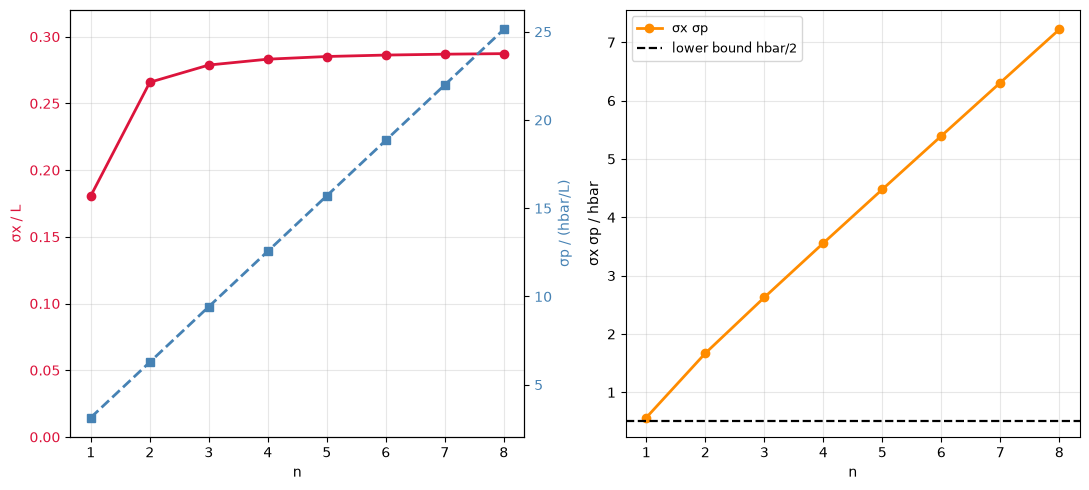

In [2]:
ns = np.arange(1, 9)
Sigma_xs, Sigma_ps, prods = [], [], []

for n in ns:
    p = psi(n)
    x_mean = np.trapezoid(p * xg * p, xg)
    x2_mean = np.trapezoid(p * xg**2 * p, xg)
    p2_mean = np.trapezoid(p * (-(hbar**2) * (D2 @ p)), xg)
    sigma_x, sigma_p = np.sqrt(x2_mean - x_mean**2), np.sqrt(p2_mean)
    Sigma_xs.append(sigma_x / L)
    Sigma_ps.append(sigma_p / (hbar / L))
    prods.append(sigma_x * sigma_p / hbar)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5))

a1.plot(ns, Sigma_xs, "o-", color="crimson", lw=2)
a1.set_xlabel("n")
a1.set_ylabel("σx / L", color="crimson")
a1.tick_params(axis="y", labelcolor="crimson")
a1.set_ylim(0, 0.32)
a1.grid(alpha=0.3)
a1b = a1.twinx()
a1b.plot(ns, Sigma_ps, "s--", color="steelblue", lw=2)
a1b.set_ylabel("σp / (hbar/L)", color="steelblue")
a1b.tick_params(axis="y", labelcolor="steelblue")

a2.plot(ns, prods, "o-", color="darkorange", lw=2, label="σx σp")
a2.axhline(0.5, color="black", ls="--", lw=1.6, label="lower bound hbar/2")
a2.set_xlabel("n")
a2.set_ylabel("σx σp / hbar")
a2.legend(fontsize=9)
a2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
X = np.diag(xg)  # 위치 연산자 (대각행렬)
P = -1j * hbar * D1  # 운동량 연산자

C = X @ P - P @ X  # 교환자

for n in [1, 2, 3, 4]:
    p = psi(n)
    value = np.trapezoid(p * (C @ p), xg)
    print(f"n = {n}: <[x, p]> = {value / (1j * hbar):.4f} x (i hbar)")

n = 1: <[x, p]> = 1.0000+0.0000j x (i hbar)
n = 2: <[x, p]> = 1.0000+0.0000j x (i hbar)
n = 3: <[x, p]> = 1.0000+0.0000j x (i hbar)
n = 4: <[x, p]> = 1.0000+0.0000j x (i hbar)


In [4]:
H = -(hbar**2) / (2 * m_e) * D2
V = np.diag(xg**2)


def commutator(A, B):
    return A @ B - B @ A


for A, B, name in [(X, V, "[x, V(x)]"), (H, H, "[H, H]  "), (X, H, "[x, H]  ")]:
    print(f"{name}: 최대 크기 = {np.max(np.abs(commutator(A, B))):.3e}")

[x, V(x)]: 최대 크기 = 0.000e+00
[H, H]  : 최대 크기 = 0.000e+00
[x, H]  : 최대 크기 = 1.832e-26
